# Data understanding and TRAIN EDA

The future project monitors brand/product sentiment. Phase 1 establishes a reproducible foundation without model training. TweetEval provides a public English tweet benchmark with official train, validation and test splits.

Source: [Cardiff NLP TweetEval](https://huggingface.co/datasets/cardiffnlp/tweet_eval). Citation: Barbieri et al. (2020), [TweetEval](https://aclanthology.org/2020.findings-emnlp.148/). TRAIN supports development; VALIDATION supports future selection; TEST remains locked. These cells load only TRAIN.

In [1]:
from pathlib import Path
import sys
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'config.py').is_file())
if str(root) not in sys.path:
    sys.path.insert(0, str(root))
from src.config import RAW_DATA_DIR, FIGURES_DIR
from src.data_loader import load_csv
from IPython.display import display, Image
train = load_csv(RAW_DATA_DIR / 'tweet_eval_train.csv')

In [2]:
display({'shape': train.shape, 'columns': list(train.columns)})
display(train.groupby('sentiment', sort=True).head(2))

{'shape': (45615, 3), 'columns': ['text', 'sentiment', 'split']}

,text,sentiment,split
0,"""QT @user In the original draft of the 7th boo...",positive,train
1,"""Ben Smith / Smith (concussion) remains out of...",neutral,train
2,Sorry bout the stream last night I crashed out...,neutral,train
4,@user Alciato: Bee will invest 150 million in ...,positive,train
7,So disappointed in wwe summerslam! I want to s...,negative,train
13,That sucks if you have to take the SATs tomorrow,negative,train


## Missing values, duplicates and balance
Mechanical checks preserve official rows. Empty strings are checked separately because literal strings such as NA must not become missing data.

In [3]:
from src.data_validation import validate_dataframe
from src.eda import analyze_train
display(validate_dataframe(train, 'train'))
analysis = analyze_train(train)
display({k: analysis[k] for k in ['class_counts', 'class_percentages', 'characters', 'words', 'artifacts']})

{'critical_errors': {},
 'warnings': {'duplicate_rows': 26, 'duplicate_text': 29},
 'counts': {'rows': 45615,
  'missing_values': {'text': 0, 'sentiment': 0, 'split': 0},
  'duplicate_rows': 26,
  'null_text': 0,
  'non_string_text': 0,
  'blank_text': 0,
  'duplicate_text': 29,
  'short_text': 0,
  'long_text': 0}}

{'class_counts': {'negative': 7093, 'neutral': 20673, 'positive': 17849},
 'class_percentages': {'negative': 15.55,
  'neutral': 45.321,
  'positive': 39.13},
 'characters': {'count': 45615.0,
  'mean': 106.93285103584347,
  'std': 26.251516803645902,
  'min': 10.0,
  '25%': 89.0,
  '50%': 113.0,
  '75%': 128.0,
  'max': 200.0},
 'words': {'count': 45615.0,
  'mean': 19.23744382330374,
  'std': 4.935989720220856,
  'min': 1.0,
  '25%': 16.0,
  '50%': 20.0,
  '75%': 23.0,
  'max': 35.0},
 'artifacts': {'url': {'rows': 88, 'percent': 0.193},
  'mention': {'rows': 13390, 'percent': 29.354},
  'hashtag': {'rows': 8526, 'percent': 18.691},
  'emoji': {'rows': 0, 'percent': 0.0}}}

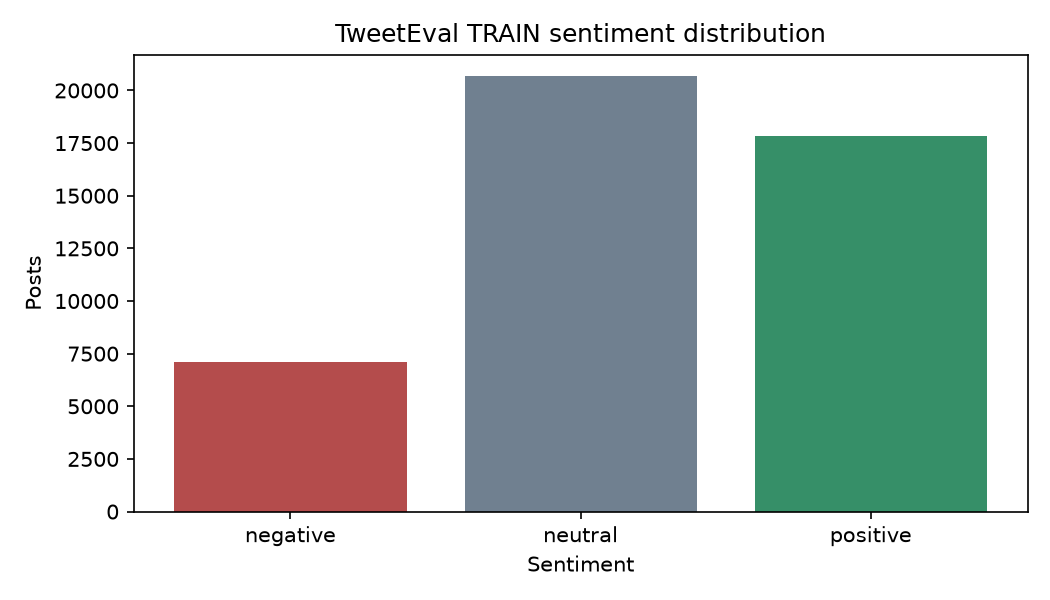

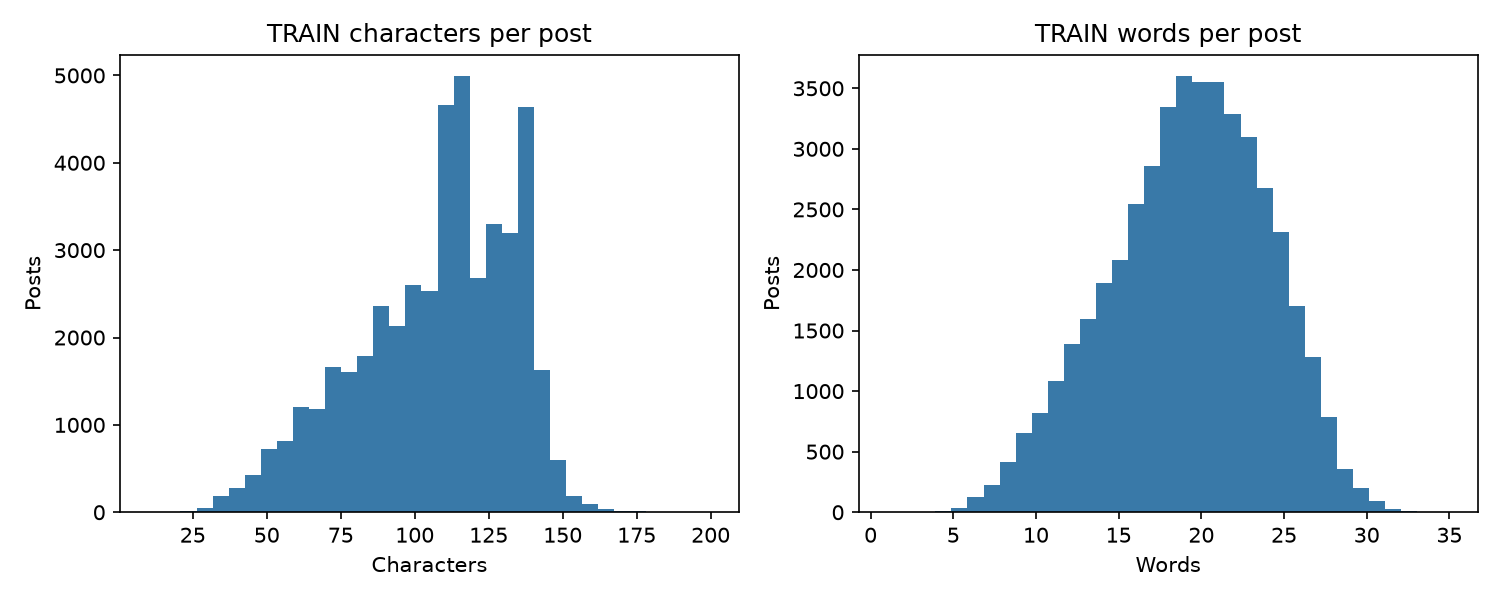

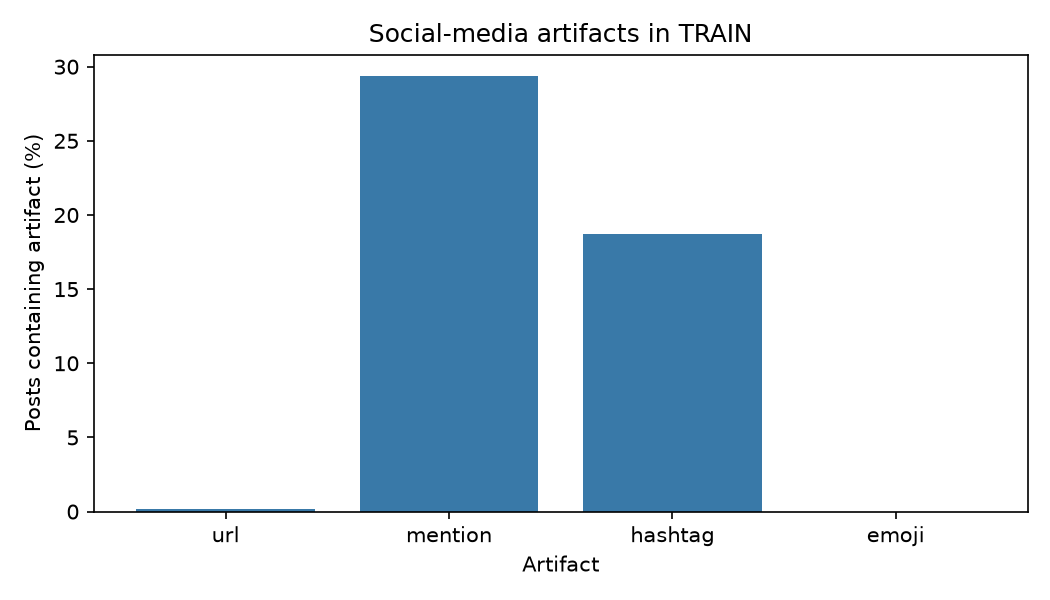

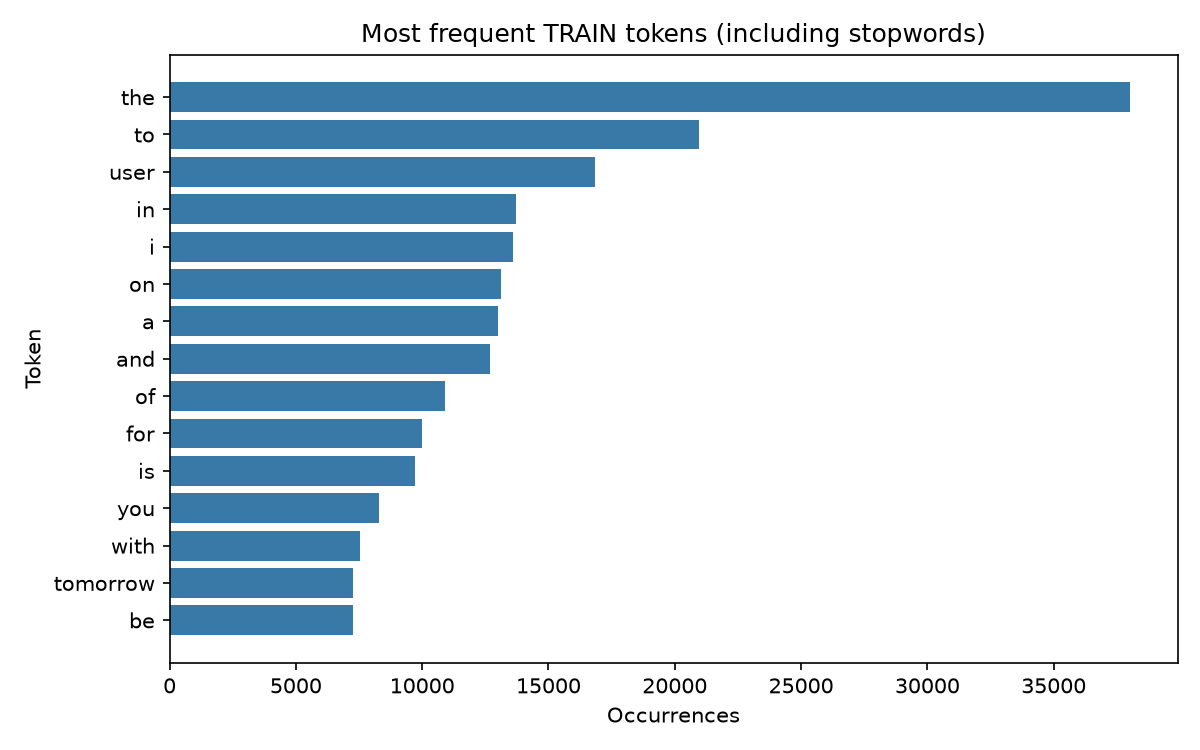

In [4]:
for filename in ['train_class_distribution.png', 'train_text_lengths.png', 'train_artifacts.png', 'train_top_tokens.png']:
    display(Image(filename=str(FIGURES_DIR / filename)))

## Frequent words and bigrams
Descriptive counts include stopwords and use a simple regex. These are not TF-IDF features. Artifact counts measure posts containing each artifact, not total occurrences.

In [5]:
display(analysis['top_tokens'])
display(analysis['top_bigrams'])
display(analysis['tokens_by_sentiment'])
display({'short': analysis['short_examples'], 'long': analysis['long_examples']})

[('the', 38002),
 ('to', 20952),
 ('user', 16840),
 ('in', 13710),
 ('i', 13612),
 ('on', 13119),
 ('a', 13006),
 ('and', 12699),
 ('of', 10896),
 ('for', 9992),
 ('is', 9706),
 ('you', 8293),
 ('with', 7543),
 ('tomorrow', 7255),
 ('be', 7252),
 ('it', 7127),
 ('at', 7118),
 ('may', 6679),
 ('that', 4669),
 ('my', 4633)]

[('in the', 3589),
 ('user user', 2678),
 ('of the', 2566),
 ('on the', 2365),
 ('for the', 2350),
 ('going to', 2223),
 ('at the', 1974),
 ('to the', 1840),
 ('may be', 1497),
 ('will be', 1283),
 ('to see', 1283),
 ('to be', 1224),
 ('is the', 982),
 ('may have', 981),
 ('user i', 958),
 ('the 1st', 946),
 ('want to', 770),
 ('and the', 742),
 ('i may', 728),
 ('be the', 719)]

{'negative': [('the', 5800),
  ('to', 3250),
  ('i', 2691),
  ('user', 2597),
  ('a', 2341),
  ('in', 2013),
  ('and', 1971),
  ('is', 1898),
  ('of', 1849),
  ('on', 1782),
  ('may', 1570),
  ('be', 1351),
  ('it', 1346),
  ('for', 1320),
  ('you', 1203),
  ('that', 1062),
  ('with', 957),
  ('not', 946),
  ('tomorrow', 919),
  ('but', 906)],
 'neutral': [('the', 17865),
  ('to', 9219),
  ('user', 7483),
  ('in', 6584),
  ('on', 6319),
  ('a', 5505),
  ('and', 5419),
  ('of', 4929),
  ('i', 4929),
  ('for', 4429),
  ('is', 3840),
  ('at', 3603),
  ('with', 3552),
  ('you', 3312),
  ('be', 2997),
  ('may', 2902),
  ('tomorrow', 2880),
  ('it', 2805),
  ('u002c', 2245),
  ('that', 2003)],
 'positive': [('the', 14337),
  ('to', 8483),
  ('user', 6760),
  ('i', 5992),
  ('and', 5309),
  ('a', 5160),
  ('in', 5113),
  ('on', 5018),
  ('for', 4243),
  ('of', 4118),
  ('is', 3968),
  ('you', 3778),
  ('tomorrow', 3456),
  ('with', 3034),
  ('it', 2976),
  ('be', 2904),
  ('at', 2851),
  ('my

{'short': [], 'long': []}

## Observations and Phase 2 risks
The executed class counts show imbalance, so future evaluation should include macro-F1 and per-class recall. Mentions and hashtag words occur frequently; raw token counts include user placeholders and common function words. No Unicode emojis were detected in this training snapshot; emoji-preservation behavior is still covered by explicit test examples for future inputs. Short historical tweets lack conversational context. Negation, sarcasm and brand-specific vocabulary remain challenging. No test distribution or examples inform these decisions. See reports/phase1_summary.md for all measured findings.